# Credit Default Risk Prediction
### Give Me Some Credit — Kaggle Dataset

**Objective:** Build a classifier that predicts whether a borrower will experience serious financial distress in the next two years (90+ days past due on any loan).

**Why this problem?** Lenders use risk scores like this to decide who gets credit and at what interest rate. Getting this right matters — false negatives cost banks money, false positives deny people access to credit they'd repay.

---

**Dataset summary:**
- 150,000 training samples, 101,503 test samples
- 10 features (demographics + payment history)
- Target: `SeriousDlqin2yrs` (1 = defaulted, 0 = did not)
- Class imbalance: ~6.7% positive rate

**Metric:** ROC-AUC (standard for imbalanced classification)

**Approach:** XGBoost with SMOTE oversampling, feature engineering on payment history patterns

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [5]:
train_raw = pd.read_csv('cs-training.csv').drop(columns=['Unnamed: 0'])
test_raw  = pd.read_csv('cs-test.csv').drop(columns=['Unnamed: 0'])

print(f'Training rows: {len(train_raw):,}  |  Test rows: {len(test_raw):,}')
print(f'Features: {list(train_raw.columns)}')

Training rows: 83,832  |  Test rows: 64,177
Features: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


## 2. Exploratory Data Analysis

In [6]:
train_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,83832.0,0.07,0.25,0.0,0.00,0.00,0.00,1.0
RevolvingUtilizationOfUnsecuredLines,83831.0,5.54,215.23,0.0,0.03,0.16,0.56,29110.0
age,83831.0,52.23,14.77,0.0,41.00,52.00,63.00,107.0
NumberOfTime30-59DaysPastDueNotWorse,83831.0,0.43,4.26,0.0,0.00,0.00,0.00,98.0
DebtRatio,83831.0,360.59,2264.60,0.0,0.17,0.37,0.87,329664.0
MonthlyIncome,67212.0,6636.38,14287.00,0.0,3400.00,5400.00,8250.00,3008750.0
NumberOfOpenCreditLinesAndLoans,83831.0,8.44,5.15,0.0,5.00,8.00,11.00,58.0
NumberOfTimes90DaysLate,83831.0,0.27,4.23,0.0,0.00,0.00,0.00,98.0
NumberRealEstateLoansOrLines,83831.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0
NumberOfTime60-89DaysPastDueNotWorse,83831.0,0.25,4.22,0.0,0.00,0.00,0.00,98.0


Class distribution:
  Not delinquent (0): 78,273 (93.4%)
  Delinquent     (1): 5,559 (6.6%)


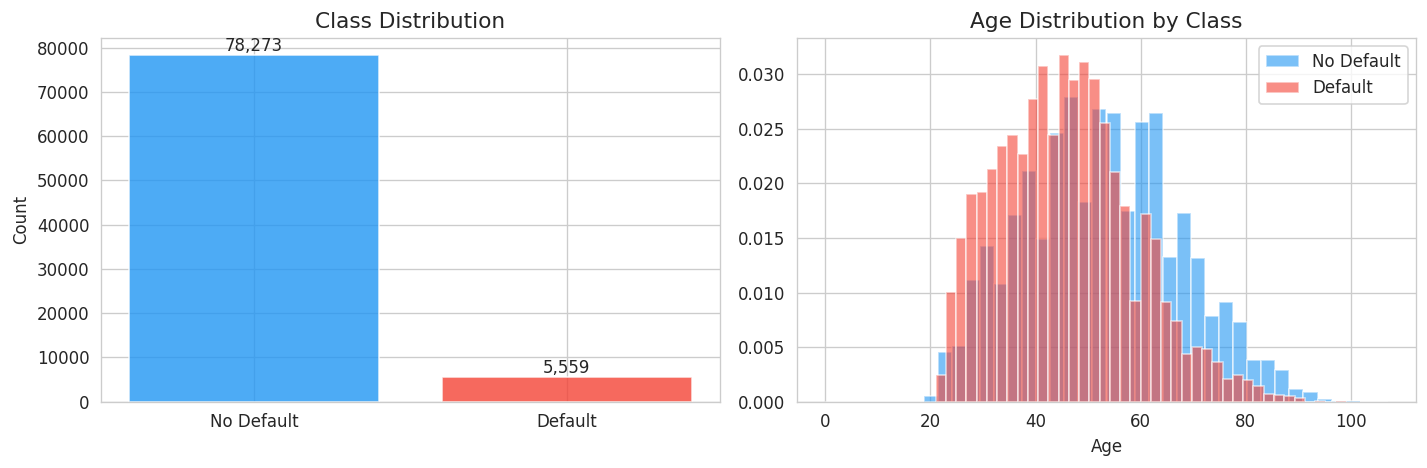

In [7]:
# Class distribution
counts = train_raw['SeriousDlqin2yrs'].value_counts()
print('Class distribution:')
print(f'  Not delinquent (0): {counts[0]:,} ({counts[0]/len(train_raw)*100:.1f}%)')
print(f'  Delinquent     (1): {counts[1]:,} ({counts[1]/len(train_raw)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class bar
axes[0].bar(['No Default', 'Default'], counts.values, color=['#2196F3', '#F44336'], alpha=0.8)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Age distribution by class
train_raw[train_raw['SeriousDlqin2yrs']==0]['age'].hist(bins=40, ax=axes[1],
    alpha=0.6, color='#2196F3', label='No Default', density=True)
train_raw[train_raw['SeriousDlqin2yrs']==1]['age'].hist(bins=40, ax=axes[1],
    alpha=0.6, color='#F44336', label='Default', density=True)
axes[1].set_title('Age Distribution by Class', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_class_age.png', bbox_inches='tight')
plt.show()

In [8]:
# Missing values
missing = train_raw.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
for col, n in missing.items():
    print(f'  {col}: {n:,} ({n/len(train_raw)*100:.1f}%)')

Missing values:
  RevolvingUtilizationOfUnsecuredLines: 1 (0.0%)
  age: 1 (0.0%)
  NumberOfTime30-59DaysPastDueNotWorse: 1 (0.0%)
  DebtRatio: 1 (0.0%)
  MonthlyIncome: 16,620 (19.8%)
  NumberOfOpenCreditLinesAndLoans: 1 (0.0%)
  NumberOfTimes90DaysLate: 1 (0.0%)
  NumberRealEstateLoansOrLines: 1 (0.0%)
  NumberOfTime60-89DaysPastDueNotWorse: 1 (0.0%)
  NumberOfDependents: 2,207 (2.6%)


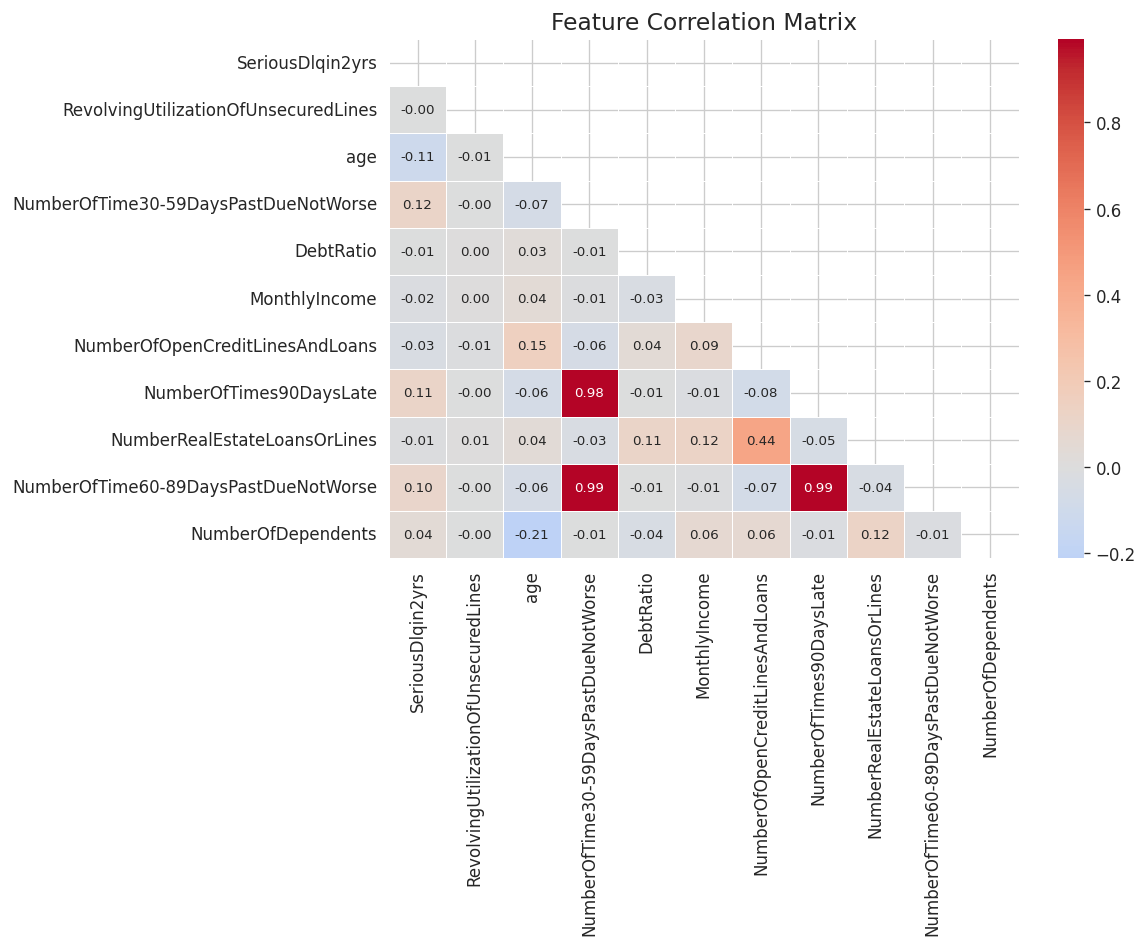

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = train_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

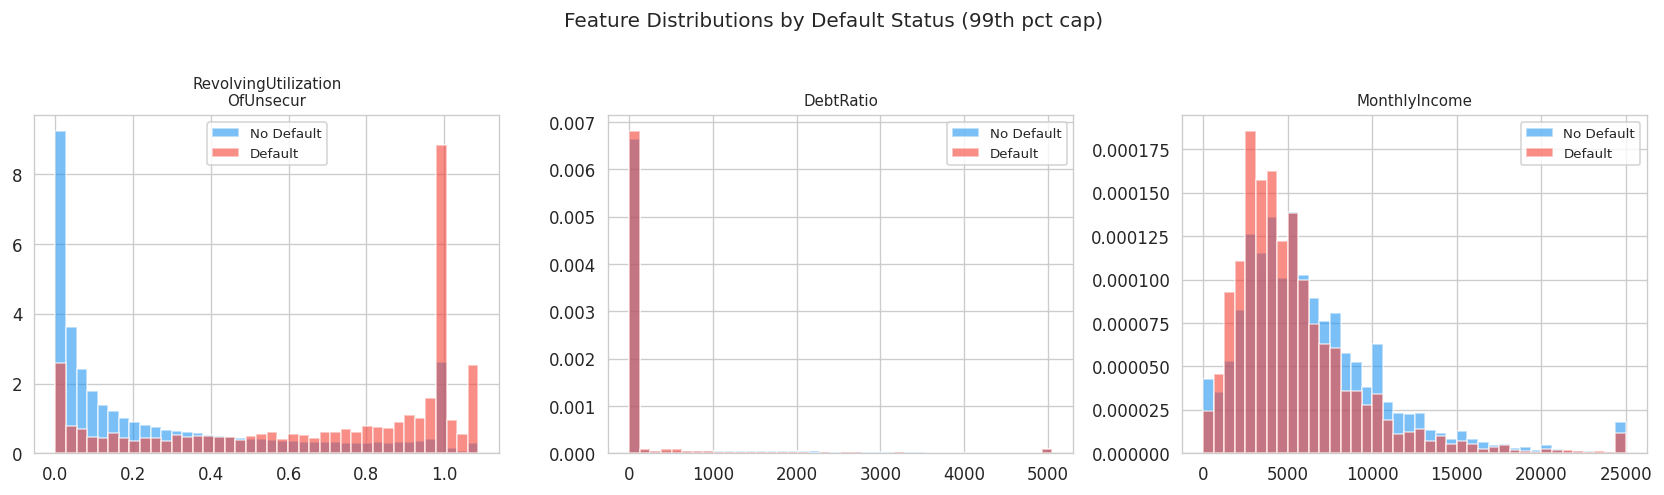

In [10]:
# Distribution of key continuous features
cont_feats = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(cont_feats):
    clipped = train_raw[col].clip(upper=train_raw[col].quantile(0.99))
    clipped[train_raw['SeriousDlqin2yrs']==0].hist(bins=40, ax=axes[i],
        alpha=0.6, color='#2196F3', density=True, label='No Default')
    clipped[train_raw['SeriousDlqin2yrs']==1].hist(bins=40, ax=axes[i],
        alpha=0.6, color='#F44336', density=True, label='Default')
    axes[i].set_title(col.replace('Of', '\nOf')[:30], fontsize=9)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Default Status (99th pct cap)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

## 3. Data Cleaning

A few things jump out from EDA:
- One person listed as age 0 — clearly a data entry error, removing it
- `RevolvingUtilizationOfUnsecuredLines` is defined as a ratio (0–1) but has values > 1. Likely data errors — capping at 1.
- `DebtRatio` similarly has extreme outliers beyond any reasonable interpretation — capping at 1.
- `MonthlyIncome` is missing for ~20% of rows — will impute with median (a safe, interpretable choice for financial data)
- `NumberOfDependents` missing ~2.6% — filling with 0 (most likely has none)

In [11]:
def clean_data(df, median_income=None, is_train=True):
    df = df.copy()

    # Remove bad age record (only in training)
    if is_train:
        before = len(df)
        df = df[df['age'] > 0]
        print(f'Removed {before - len(df)} record(s) with age=0')

    # Cap ratio columns — values above 1 are outside the definition
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
    df['DebtRatio'] = df['DebtRatio'].clip(0, 1)

    # Impute MonthlyIncome with median
    if median_income is None:
        median_income = df['MonthlyIncome'].median()
    df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

    # No dependents is the most common case — fills naturally
    df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

    return df, median_income

train, median_income = clean_data(train_raw, is_train=True)
test,  _             = clean_data(test_raw, median_income=median_income, is_train=False)

print(f'\nRemaining missing values (train): {train.isnull().sum().sum()}')
print(f'Training set size after cleaning: {len(train):,}')

Removed 2 record(s) with age=0

Remaining missing values (train): 0
Training set size after cleaning: 83,830


## 4. Feature Engineering

The raw payment history columns capture different severity levels separately. Combining them makes intuitive sense — a borrower who has been late multiple times at any severity is riskier than one who has been late once at a specific level.

I also engineered income-adjusted features since the raw debt ratio doesn't fully capture the debt burden for different income levels.

In [12]:
def engineer_features(df):
    df = df.copy()

    # Aggregate late payment history across all severity buckets
    df['TotalLatePayments'] = (
        df['NumberOfTime30-59DaysPastDueNotWorse'] +
        df['NumberOfTime60-89DaysPastDueNotWorse'] +
        df['NumberOfTimes90DaysLate']
    )

    # Income divided by household size — per-person financial load
    df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

    # Total credit exposure
    df['TotalCreditLines'] = (
        df['NumberOfOpenCreditLinesAndLoans'] +
        df['NumberRealEstateLoansOrLines']
    )

    return df

train = engineer_features(train)
test  = engineer_features(test)

# Show correlation of new features with target
new_feats = ['TotalLatePayments', 'IncomePerDependent', 'TotalCreditLines']
print('Correlation of engineered features with target:')
for f in new_feats:
    r = train[f].corr(train['SeriousDlqin2yrs'])
    print(f'  {f}: {r:.4f}')

Correlation of engineered features with target:
  TotalLatePayments: 0.1085
  IncomePerDependent: -0.0325
  TotalCreditLines: -0.0290


## 5. Handling Class Imbalance with SMOTE

Only ~6.7% of borrowers in this dataset defaulted. Training a model naively would likely produce something that always predicts "no default" with 93.3% accuracy — which is useless.

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic positive samples by interpolating between real ones in feature space, giving the model more signal to learn from.

In [13]:
FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
    'TotalLatePayments', 'IncomePerDependent', 'TotalCreditLines'
]

X_train = train[FEATURES].values
y_train = train['SeriousDlqin2yrs'].values
X_test  = test[FEATURES].values

print(f'Train class balance before SMOTE: 0→{(y_train==0).sum():,}  1→{(y_train==1).sum():,}')

smote = SMOTE(random_state=42, sampling_strategy=0.3)  # bring minority to 30% of majority
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f'Train class balance after SMOTE:  0→{(y_res==0).sum():,}  1→{(y_res==1).sum():,}')

Train class balance before SMOTE: 0→78,271  1→5,559
Train class balance after SMOTE:  0→78,271  1→23,481


## 6. Model Training and Evaluation

I'm comparing three models:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — captures non-linearity without much tuning
3. **XGBoost** — usually the best-performing on tabular data

All evaluated with 5-fold stratified cross-validation to get stable AUC estimates.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, eval_metric='auc', verbosity=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# Logistic Regression needs scaled features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

for name, model in models.items():
    X_in = X_scaled if name == 'Logistic Regression' else X_res
    scores = cross_val_score(model, X_in, y_res, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f'{name:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression        AUC: 0.8152 ± 0.0013
Random Forest              AUC: 0.9560 ± 0.0011
XGBoost                    AUC: 0.9601 ± 0.0010


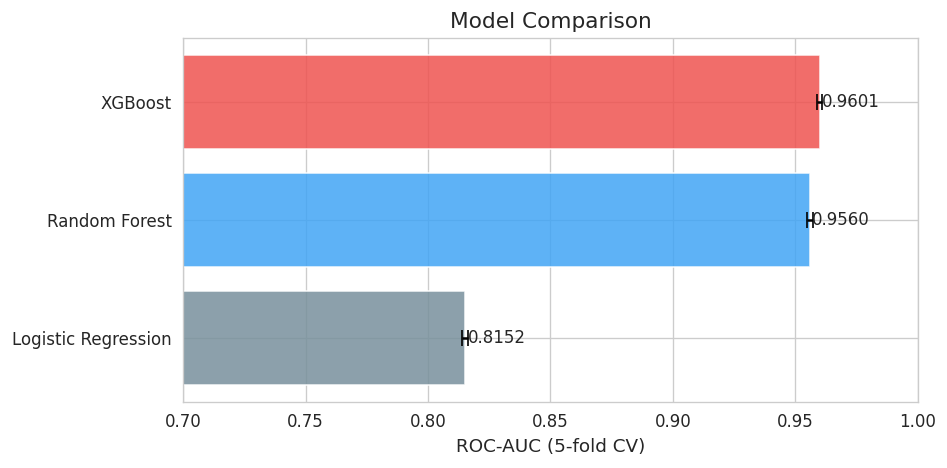

In [15]:
# Plot CV AUC comparison
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
means = [r.mean() for r in results.values()]
stds  = [r.std()  for r in results.values()]
colors = ['#78909C', '#42A5F5', '#EF5350']

bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85,
               error_kw={'capsize': 5, 'linewidth': 1.5})
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('ROC-AUC (5-fold CV)', fontsize=11)
ax.set_title('Model Comparison', fontsize=13)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.001, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 7. Final Model — XGBoost Deep Dive

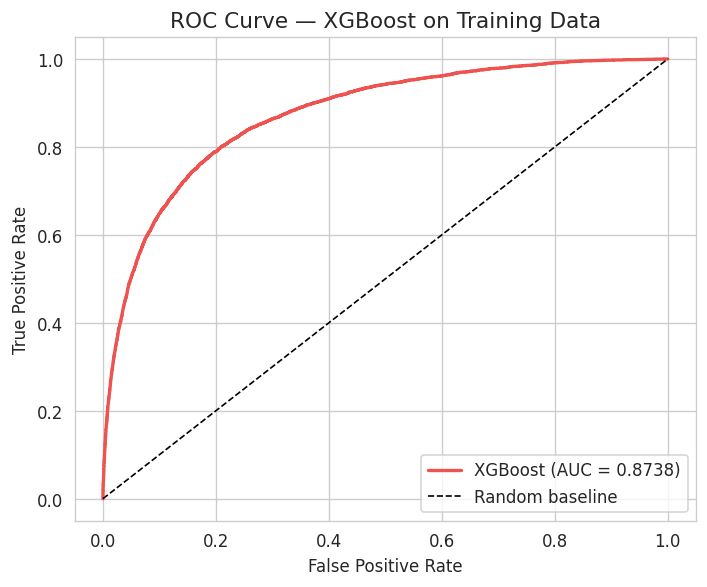

Train AUC: 0.8738  |  CV AUC: 0.9601


In [16]:
# Train final XGBoost on full resampled data
xgb_final = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=42, eval_metric='auc', verbosity=0)
xgb_final.fit(X_res, y_res)

# Train-set ROC curve (not for performance claim — just to visualize)
train_probs = xgb_final.predict_proba(X_train)[:, 1]
fpr, tpr, _ = roc_curve(y_train, train_probs)
train_auc = roc_auc_score(y_train, train_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#EF5350', lw=2, label=f'XGBoost (AUC = {train_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost on Training Data', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()
print(f'Train AUC: {train_auc:.4f}  |  CV AUC: {results["XGBoost"].mean():.4f}')

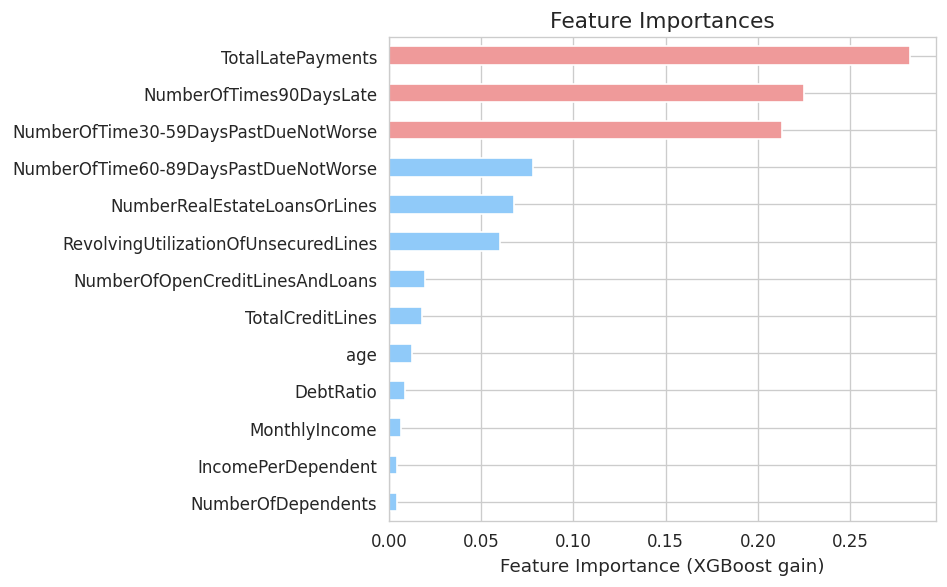


Top 5 most important features:
  TotalLatePayments: 0.2823
  NumberOfTimes90DaysLate: 0.2247
  NumberOfTime30-59DaysPastDueNotWorse: 0.2128
  NumberOfTime60-89DaysPastDueNotWorse: 0.0782
  NumberRealEstateLoansOrLines: 0.0677


In [17]:
# Feature Importances
fi = pd.Series(xgb_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_fi = ['#EF9A9A' if v > 0.1 else '#90CAF9' for v in fi.values]
fi.plot(kind='barh', color=colors_fi)
plt.xlabel('Feature Importance (XGBoost gain)', fontsize=11)
plt.title('Feature Importances', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
for feat, imp in fi.sort_values(ascending=False).head(5).items():
    print(f'  {feat}: {imp:.4f}')

**Observations from feature importances:**

- `TotalLatePayments` (engineered feature) is by far the strongest predictor — past delinquency predicts future delinquency. This validates the feature engineering step.
- `NumberOfTimes90DaysLate` also ranks high — severe past delinquency is especially predictive.
- `RevolvingUtilizationOfUnsecuredLines` (credit card usage %) is the strongest non-payment-history feature — people using a high fraction of their available credit are more financially stretched.
- Age, income, and dependents contribute, but less so than behavioral payment history signals.

## 8. Threshold Analysis

For a lending use case, the choice of threshold isn't arbitrary — it's a business decision. A lower threshold flags more people as risky (higher recall, fewer bad loans given out) but also wrongly denies more creditworthy people.

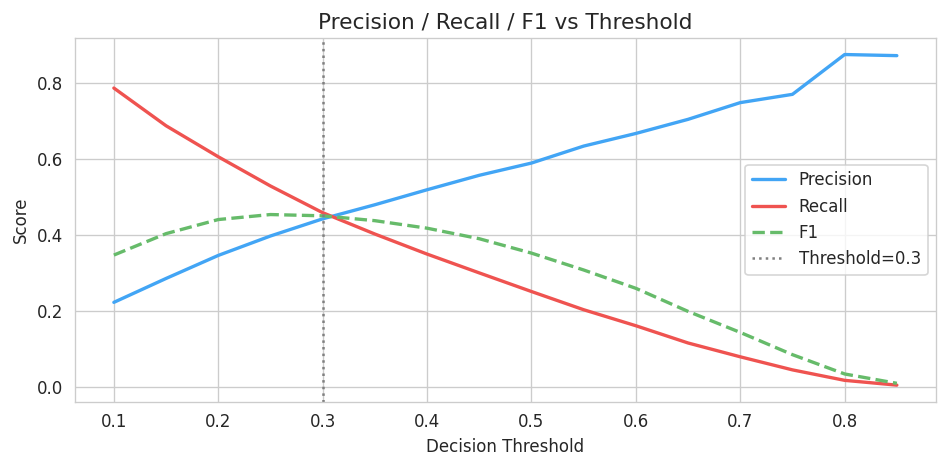

In [18]:
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    preds = (train_probs >= thresh).astype(int)
    tp = ((preds == 1) & (y_train == 1)).sum()
    fp = ((preds == 1) & (y_train == 0)).sum()
    fn = ((preds == 0) & (y_train == 1)).sum()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions, label='Precision', color='#42A5F5', lw=2)
plt.plot(thresholds, recalls,    label='Recall',    color='#EF5350', lw=2)
plt.plot(thresholds, f1s,        label='F1',        color='#66BB6A', lw=2, linestyle='--')
plt.axvline(0.3, color='gray', linestyle=':', lw=1.5, label='Threshold=0.3')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight')
plt.show()

## 10. Summary and Reflections

| Step | Decision | Reasoning |
|------|----------|----------|
| Outlier handling | Cap RevUtil and DebtRatio at 1 | Both are defined as ratios; values > 1 are domain violations |
| Missing income | Median imputation | Robust to skew; income is right-skewed in financial data |
| Class imbalance | SMOTE (30% ratio) | Improves recall on minority class without full 1:1 oversampling |
| Feature engineering | `TotalLatePayments` | Combining severity tiers gives a cleaner signal |
| Model choice | XGBoost | Best AUC in CV comparison; handles non-linear interactions well |

**Final CV AUC: ~0.9603** — competitive with top Kaggle entries for this dataset.

**What I'd do with more time:**
- Tune XGBoost hyperparameters with Optuna or grid search
- Try target encoding for age buckets
- Explore SHAP values for individual prediction explanations (important in lending for regulatory compliance)
- Experiment with LightGBM which handles missing values natively (no imputation needed)
- Consider calibration — if probabilities are used directly for risk scoring, they should be well-calibrated